## Tarea 2
Programa Experto en Inteligencia Artificial con Python  
ML3006 - Web Mining en Python  
Estudiante: Natalia Bonilla Villalobos.  
**Text Mining**

<a id="menu"></a>

# Menú
- [Ejercicio 1](#ej1)
- [Ejercicio 2](#ej2)

In [475]:
from urllib.request import Request, urlopen
from bs4 import BeautifulSoup
from io import StringIO
import pandas as pd
import numpy as np
import requests
import time
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

<a id="ej1"></a>
# Ejercicio 1

[50 puntos] En la página web 20minutos se encuentra una noticia con la agenda deportiva de
la semana del 8 al 14 de noviembre, el titular puede ser accedido presionando [aquí](https://www.20minutos.es/deportes/noticia/4882726/0/agenda-deportiva-814-noviembre/). Obtenga el
url y realice lo siguiente:

- a) Obtenga todo texto que tenga relación con los encuentros deportivos de la semana.
- b) Mediante expresiones regulares obtenga cada uno de los encuentros en una lista.
- c) Mediante expresiones regulares obtenga los encuentros con exactamente 2 equipos.
- d) Mediante expresiones regulares obtenga un data.frame que contenga 3 columnas: el tipo de competición, el equipo local y el equipo visitante. Limpie el texto en caso de ser necesario.

[↑ Volver al Menú](#menu)

## Parte 1
- a) Obtenga todo texto que tenga relación con los encuentros deportivos de la semana.

In [2]:
# Tipo de página: 
# - Es un artículo de una página.  

# Contenedor principal: <div class="c-detail__body __hnads_custom_targetings" data-custom-targetings="{&quot;debugBlocks&quot;:&quot;20_06&quot;}"> 
#   - Cada ítem:  
#     - Título: h2.c-paragraph__title  
#     - Párrafo: p.c-paragraph  -> (puede ser 1 o varios parrafos antes de llegar al siguente h2)  

In [3]:
url = "https://www.20minutos.es/deportes/noticia/4882726/0/agenda-deportiva-814-noviembre/"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36'
    }

response = requests.get(url, headers=headers)
print(f"Status code: {response.status_code}")

Status code: 200


In [4]:
soup = BeautifulSoup(response.content, 'html.parser')
article_container = soup.find('div', class_='c-detail__body')
print(f"\nAgenda Deportiva Encontrada?: {article_container is not None}")


Agenda Deportiva Encontrada?: True


In [5]:
titulos = article_container.find_all('h2', class_='c-paragraph__title')
print(f"titulos encontrados: {len(titulos)}")

parrafos = article_container.find_all('p', class_='c-paragraph')
print(f"parrafos encontrados: {len(parrafos)}")

titulos encontrados: 7
parrafos encontrados: 39


In [6]:
texto_completo = []
for p in parrafos:
    texto = p.get_text(strip=True)
    texto_completo.append(texto)

In [7]:
# Eliminamos el primero <p> que no contenia informacion sobre los encuentros deportivos
parrafos = texto_completo[1:]
parrafos

['21:00 - Segunda División: Tenerfe vs. Girona',
 '1:00 - NBA: Chicago Bulls vs. Brooklyn Nets',
 '14:10 - Next Gen ATP Finals: Round Robin',
 '20:30 - Champions League Baloncesto: Baxi Manresa vs. Pinar Karsiyaka',
 "21:00 - Women's Champions League: PSG vs. Real Madrid",
 '1:30 - NBA: Milwaukee Bucks vs. Philadelphia 76ers',
 '14:10 - Next Gen ATP Finals: Round Robin',
 "18:45 -\xa0\xa0Women's Champions League: FC Barcelona vs. Hoffenheim",
 '20:30 -\xa0Champions League Baloncesto: Lenovo Tenerife vs. BC Promptey',
 '21:00 - WTA Finals: Round Robin',
 '4:00 - NBA: Los Angeles Lakers vs. Miami Heat',
 '20:45 - Clasificación Mundial Catar 2022: Grecia vs. España',
 '21:00 - Euroliga: Barça vs. Bitci Baskonia',
 '1:30 -\xa0Clasificación Mundial Catar 2022: Brasil vs. Colombia',
 '20:00 - GP Brasil F1: Clasificación',
 '20:45 - Euroliga: Real Madrid vs. Zalgiris Kaunas',
 '20:45 - Clasificación Mundial Catar 2022: Italia vs. Suiza',
 '21:00 - Segunda División: Sporting vs. Real Sociedad 

## Parte 2
- b) Mediante expresiones regulares obtenga cada uno de los encuentros en una lista.

In [8]:
elimina_hora = r'([\d:]+\s-\s)' # 1:00 - 
elimina_liga = r"^[\w\s\']+:\s"
elimina_competicion = r"^[\w\'\s]+\W\s[\w\s]+"

In [9]:
# re.search() → buscar
# re.sub() → reemplazar/eliminar

In [10]:
# pattern_encuentros = r'(\d{1,2}:\d{2})\s+-\s+([^:]+):\s+([^yey]+?)(?:\s+(?:y|e)\s+([^:]+?)(?:\s+vs\.?\s+([^)]+))?)?\s+vs\.?\s+([^,]+)'

In [11]:
# Se elimina solo la hora
lista_encuentros = []
for lista in parrafos:
    result = re.sub(elimina_hora, '', lista)
    # result = re.sub(elimina_liga, '', result)
    lista_encuentros.append(result)
    
lista_encuentros[:10]

['Segunda División: Tenerfe vs. Girona',
 'NBA: Chicago Bulls vs. Brooklyn Nets',
 'Next Gen ATP Finals: Round Robin',
 'Champions League Baloncesto: Baxi Manresa vs. Pinar Karsiyaka',
 "Women's Champions League: PSG vs. Real Madrid",
 'NBA: Milwaukee Bucks vs. Philadelphia 76ers',
 'Next Gen ATP Finals: Round Robin',
 "\xa0Women's Champions League: FC Barcelona vs. Hoffenheim",
 'Champions League Baloncesto: Lenovo Tenerife vs. BC Promptey',
 'WTA Finals: Round Robin']

## Parte 3

- c) Mediante expresiones regulares obtenga los encuentros con exactamente 2 equipos.

In [12]:
# pattern_2_equipos = r'\d{1,2}:\d{2}\s+-\s+[^:]+:\s+([^v]+?)\s+vs\.?\s+([^yey,]+?)(?=\s*(?:$|,|\s+y\s+|\s+e\s+))'

encuentros_2_equipos = []
for encuentro in lista_encuentros:
    # validacion que no hayan y o e despues del vs
    if not re.search(r'vs\.?\s+[^yey]+?\s+(?:y|e)\s+', encuentro, re.IGNORECASE):
        # solo agregamos un encuentro
        if len(re.findall(r'vs\.?', encuentro, re.IGNORECASE)) == 1:
            encuentros_2_equipos.append(encuentro)

encuentros_2_equipos

['Segunda División: Tenerfe vs. Girona',
 'NBA: Chicago Bulls vs. Brooklyn Nets',
 'Champions League Baloncesto: Baxi Manresa vs. Pinar Karsiyaka',
 "Women's Champions League: PSG vs. Real Madrid",
 'NBA: Milwaukee Bucks vs. Philadelphia 76ers',
 "\xa0Women's Champions League: FC Barcelona vs. Hoffenheim",
 'Champions League Baloncesto: Lenovo Tenerife vs. BC Promptey',
 'NBA: Los Angeles Lakers vs. Miami Heat',
 'Clasificación Mundial Catar 2022: Grecia vs. España',
 'Euroliga: Barça vs. Bitci Baskonia',
 'Clasificación Mundial Catar 2022: Brasil vs. Colombia',
 'Euroliga: Real Madrid vs. Zalgiris Kaunas',
 'Clasificación Mundial Catar 2022: Italia vs. Suiza',
 'Segunda División: Sporting vs. Real Sociedad B',
 'NBA: Boston Celtics vs. Milawukee Bucks',
 'Golden State Warriors vs. Chicago Bulls',
 'Segunda División: Valladolid vs. Fuenlabrada',
 'Segunda División: Las Palmas vs. Zaragoza',
 'Segunda División: Amorebieta vs. Lugo',
 'ACB: Betis vs. Tenerife',
 'ACB: Barça vs. Valencia 

## Parte 4

- d) Mediante expresiones regulares obtenga un data.frame que contenga 3 columnas: el tipo de competición, el equipo local y el equipo visitante. Limpie el texto en caso de ser necesario.

In [13]:
# # obtencion_equipos = r"^[\w\'\s]+\:\s[\w\s]+(\w{2}\W)\s[\w\s\d]+"
obtener_competencia = r"^([\w\'\s]+[\w\W\w]+):"
# comprobacion_solo_comp_equipos = r"^([\w\'\s]+[\w\W\w]+):\s[\w\s]+(\w{2}\W)\s[\w\s\d]+"
# sin_competencia = r"^[\w\s\W]+(\w{2}\W)\s[\w\s\d]+"
# obtener_equipo_local = r"(^[\w\s]+)(\w{2}\W)(\s[\w\s\d]+)|([[:<:]]y|e)(\s[\w\s]+)(\w{2}\W)(\s[\w\s\d]+)"
obtiene_grupos_competencias = r"^([\w\'\s]+[\w\W\w]+):(\s[\w\s]+)(\w{2}\W)(\s[\w\s\d]+)([[:<:]]y|e)(\s[\w\s]+)(\w{2}\W)(\s[\w\s\d]+)"

In [19]:
# lista_encuentros
col_hora = []
validacion = []
col_competicion = []
col_equipo_local = []
col_equipo_visita = []
comodin = np.nan
for encuentro in lista_encuentros:
    # =============================================
    # Se busca la hora, guarda y luego se elimina
    # =============================================
    hora = re.search(elimina_hora, encuentro)
    # col_hora.append(hora)
    encuentro = re.sub(elimina_hora, '', encuentro)
    
    # ==============================================================
    # Buscamos solo tipo de competicion, guarda y luego se eliminar
    # ==============================================================
    
    """
        Validamos que en cada iteracion solo tengamos los match y
        eliminamos espacios
    """
    # val_encuentro = re.search(comprobacion_solo_comp_equipos, encuentro)
    val_encuentro = re.search(obtiene_grupos_competencias, encuentro)
    if val_encuentro:
        val_encuentro = val_encuentro.group(0).replace('\xa0', '')
        encuentro = val_encuentro

    validacion.append(val_encuentro)
    # print(encuentro)

    """
        Luego de la validacion, usamos los datos para guardar
        y eliminar la competiciones.
    """
    competicion = re.search(obtener_competencia, encuentro)
    if competicion:
        col_competicion.append(competicion.group(0).replace(':', ''))
        encuentro = re.sub(obtener_competencia, '', encuentro)
    else:
        col_competicion.append(comodin)

    # ======================================================
    # Buscamos por equipos en grupos y guardar
    # ======================================================
    pattern = r'([\wÁÉÍÓÚÜÑáéíóúüñçÇ\s\.]+?)\s+vs\.?\s+([\wÁÉÍÓÚÜÑáéíóúüñçÇ\s\.]+)'        
    matches = re.findall(pattern, encuentro)
    if not matches:
        col_equipo_local.append(comodin)
        col_equipo_visita.append(comodin)
    else:
        for local, visitante in matches:
            col_equipo_local.append(local.strip())
            col_equipo_visita.append(visitante.strip())
              
# print('columnas hora:')
# print(col_hora[:5])
# print(len(col_hora))
print('columnas competicion:')
print(col_competicion[:5])
print(len(col_competicion))
print('columnas equipo Local:')
print(col_equipo_local[:5])
print(len(col_equipo_local))
print('columnas equipo Visita:')
print(col_equipo_visita[:5])
print(len(col_equipo_visita))


columnas competicion:
['Segunda División', 'NBA', 'Next Gen ATP Finals', 'Champions League Baloncesto', "Women's Champions League"]
38
columnas equipo Local:
['Tenerfe', 'Chicago Bulls', nan, 'Baxi Manresa', 'PSG']
38
columnas equipo Visita:
['Girona', 'Brooklyn Nets', nan, 'Pinar Karsiyaka', 'Real Madrid']
38


In [21]:
# Antes de generar el data frame, hay que dividir los equipos que estan dobles y agregarlos a otra row
# Copiamos las listas originales
# nueva_hora = []
nueva_comp = []
nuevo_local = []
nuevo_visita = []

for i in range(len(col_equipo_visita)):
    visita = col_equipo_visita[i]
    local = col_equipo_local[i]
    
    # Si el visitante tiene y|e
    if ' y ' in str(visita) or ' e ' in str(visita):
        # Construir el texto completo con el local + el visitante
        texto_completo = local + ' vs. ' + visita
        partes = re.split(r' y | e ', texto_completo)
        # print(partes)
        
        for parte in partes:
            # 2 grupos, local y visita
            match = re.search(r'([\w\s\.]+?)\s+vs\.?\s+([\w\s\.]+)', parte)
            if match:
                nuevo_local.append(match.group(1).strip())
                nuevo_visita.append(match.group(2).strip())
            else:
                nuevo_local.append(comodin)
                nuevo_visita.append(parte.strip())
            
            # nueva_hora.append(col_hora[i])
            nueva_comp.append(col_competicion[i])
    else:
        # Caso normal
        # nueva_hora.append(col_hora[i])
        nueva_comp.append(col_competicion[i])
        nuevo_local.append(local)
        nuevo_visita.append(visita)

In [22]:
# print('columnas hora:')
# print(nueva_hora[:5])
# print(len(nueva_hora))
print('columnas competicion:')
print(nueva_comp[:5])
print(len(nueva_comp))
print('columnas equipo Local:')
print(nuevo_local[:5])
print(len(nuevo_local))
print('columnas equipo Visita:')
print(nuevo_visita[:5])
print(len(nuevo_visita))

columnas competicion:
['Segunda División', 'NBA', 'Next Gen ATP Finals', 'Champions League Baloncesto', "Women's Champions League"]
44
columnas equipo Local:
['Tenerfe', 'Chicago Bulls', nan, 'Baxi Manresa', 'PSG']
44
columnas equipo Visita:
['Girona', 'Brooklyn Nets', nan, 'Pinar Karsiyaka', 'Real Madrid']
44


In [45]:
agenda_deportiva = pd.DataFrame({
    'Tipo Competición' : nueva_comp,
    'Equipo Local' : nuevo_local,
    'Equipo Visitante' : nuevo_visita,
})

In [35]:
agenda_deportiva.sample(5)

,Tipo Competición,Equipo Local,Equipo Visitante
40,Segunda División,Leganés,Oviedo
21,Segunda División,Valladolid,Fuenlabrada
18,NBA,Boston Celtics,Milawukee Bucks
31,ACB,Fuenlabrada,Real Madrid
39,Segunda División,Burgos,Ponferradina


In [53]:
agenda_deportiva.shape

(44, 3)

In [56]:
df = agenda_deportiva.copy()

In [66]:
# para el Golden Warrior que son de la NBA
df['Tipo Competición'] = df['Tipo Competición'].ffill()
df[18:22]


,Tipo Competición,Equipo Local,Equipo Visitante
18,NBA,Boston Celtics,Milawukee Bucks
19,NBA,Golden State Warriors,Chicago Bulls
20,MotoGP Comunidad Valenciana,NaN,NaN
21,Segunda División,Valladolid,Fuenlabrada


In [67]:
# Eliminar registros donde algún equipo sea NaN o esté vacío
df = df[(df['Equipo Local'] != 'NaN') & (df['Equipo Visitante'] != 'NaN')]
df = df[df['Equipo Local'].str.len() > 0]
df = df[df['Equipo Visitante'].str.len() > 0]
df.shape

(35, 3)

In [68]:
# se guardan los datos
df.to_csv("tabla_agenda_deportiva.csv", index=False, encoding="utf-8")
print('tabla_agenda_deportiva.csv -> Gurardad')

tabla_agenda_deportiva.csv -> Gurardad


<a id="ej2"></a>
# Ejercicio 2

[50 puntos] Artesanos Car Club es una tienda de vehículos. Para este ejercicio extraeremos información del enlace que se encuentra presionando [aquí](https://artesanoscarclub.com/vehiculos-usados/). Obtenga el url y obtenga una tabla
de datos de todos los productos disponibles que se encuentran en el sitio web:

Su tarea consiste en:  

- a) Obtenga el nombre, el precio, el año, el kilometraje, el motor y el tipo de combustible de un vehículo.
- b) Obtenga el elemento con el enlace del siguiente conjunto de vehículos.
- c) Realice un ciclo para obtener la información de todos los vehículos disponibles, deben ser los mismos datos que se solictan en el primer inciso.
- d) Con los resultados anteriores genere un Dataframe.
- e) Realice una limpieza de los datos.
- f) Muestre con un gráfico los 10 vehiculos más usados (con más kilometraje).
- g) Aplique a la variable con el tipo de combustible código disyuntivo completo.
- h) Muestre con un gráfico la matriz de correlaciones. Interprete al menos dos correlaciones.  


[↑ Volver al Menú](#menu)

## Verificación de Conectividad y Respuesta del Servidor

In [497]:
# url = "https://artesanoscarclub.com/vehiculos-usados/"
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36'
}

response  = requests.get(url, headers=headers)
print(f"Status code: {response.status_code}")
print(response.text[:500])  # primeros 500 caracteres para ver qué llega


Status code: 200
<!doctype html>
<html lang="es">
<head>
	<meta charset="UTF-8">
	<meta name="viewport" content="width=device-width, initial-scale=1">
	<link rel="profile" href="https://gmpg.org/xfn/11">
	<meta name='robots' content='index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1' />
<!-- Etiqueta de Google (gtag.js) modo de consentimiento dataLayer añadido por Site Kit -->
<script id="google_gtagjs-js-consent-mode-data-layer">
window.dataLayer = window.dataLayer || [];function gtag


In [500]:
soup = BeautifulSoup(response.content, 'html.parser')
vehicles_container = soup.find('div', id='vehiculos-loop')

print(f"\nVehiculos encontrados?: {vehicles_container is not None}")


Vehiculos encontrados?: True


In [501]:
vehicles_container

<div id="vehiculos-loop"></div>

El contenido se estaba imprimiendo vacío, aunque el div si exitía.  
Por lo que investigando, me di cuenta que el contenido del vehículo se está cargando de forma dinámica.

Para esto se investiga que se debe de tomar el url del ajax que sale en el inspector > Network y filtrando en el tab 'Fetch', refrescando la página.  
Nos muestra varios archivos en los que debemos buscar el tab 'Payload' para identificar el archivo que trae todos los vehículos, identificando el parámetro con la acción.  
Por lo que en los `headers` llenamos los que vienen en el Network del inspector (para 'fingir' que somos un navegador y que no nos bloquee) al igual que en la variable `payload`.  

La petición que se encontró fue una petición POST a: https://artesanoscarclub.com/wp-admin/admin-ajax.php  
con el parámetro con la acción: `action` = `ajax_sort_vehiculos`.

In [ ]:
ajax_url = "https://artesanoscarclub.com/wp-admin/admin-ajax.php"

# Headers que simulan una petición legítima desde el navegador
headers = {
    'User-Agent':       'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36',
    'accept':           '*/*',
    'accept-language':  'en-US,en;q=0.9,es;q=0.8',
    'origin':           'https://artesanoscarclub.com',
    'referer':          'https://artesanoscarclub.com/vehiculos-usados/',
    'sec-fetch-dest':   'empty',
    'sec-fetch-mode':   'cors',
    'sec-fetch-site':   'same-origin',
}

# Payload: parámetros que el servidor necesita para devolver los vehículos.
# 'page' se actualiza en cada iteración del ciclo de paginación.
payload = {
    'action':          'ajax_sort_vehiculos',
    'sort':            'date_desc',
    'page':            '1',
    'filtros':         '',
    'por_pagina':      '30',
    'incluir_orden':   'true',
    'incluir_filtros': 'true',
    'marca':           '',
    'modelo':          '',
    'plantilla':       '1046'
}

resp = requests.post(ajax_url, headers=headers, data=payload)
print(f"Status code: {resp.status_code}")
print(resp.text[:500])

Status code: 200
{"html":"<style>.elementor-1046 .elementor-element.elementor-element-df4d4c4{--display:flex;--flex-direction:column;--container-widget-width:100%;--container-widget-height:initial;--container-widget-flex-grow:0;--container-widget-align-self:initial;--flex-wrap-mobile:wrap;--gap:0px 0px;--row-gap:0px;--column-gap:0px;border-style:solid;--border-style:solid;border-width:2px 2px 2px 2px;--border-top-width:2px;--border-right-width:2px;--border-bottom-width:2px;--border-left-width:2px;border-color:#F


In [136]:
# El response es JSON, no HTML directo
data = resp.json()

# El HTML de los vehículos está en la clave "html"
soup = BeautifulSoup(data['html'], 'html.parser')

# Cada vehículo
vehiculos = soup.find_all(attrs={"data-elementor-type": "loop-item"})

print(f"Vehículos en esta página: {len(vehiculos)}")

Vehículos en esta página: 30


## Parte 1
- a) Obtenga el nombre, el precio, el año, el kilometraje, el motor y el tipo de combustible de un vehículo.

In [201]:
vehiculo = vehiculos[0]
vehiculo

<div class="elementor elementor-1046 e-loop-item e-loop-item-4608 post-4608 type-vehiculo status-publish has-post-thumbnail hentry ano-del-vehiculo-186 combustible-electrico etiqueta-de-vehiculo-verified marca-lyriq pasajeros-202 tipo-de-vehiculo-electricos tipo-de-vehiculo-suv tipo-de-vehiculo-todos traccion-4x4" data-custom-edit-handle="1" data-elementor-id="1046" data-elementor-post-type="elementor_library" data-elementor-type="loop-item">
<div class="elementor-element elementor-element-df4d4c4 wrap-car-card e-flex e-con-boxed e-con e-parent" data-e-type="container" data-element_type="container" data-id="df4d4c4">
<div class="e-con-inner">
<div class="elementor-element elementor-element-3b11af3 e-con-full e-flex e-con e-child" data-e-type="container" data-element_type="container" data-id="3b11af3">
<div class="elementor-element elementor-element-f2c8a35 elementor-absolute elementor-widget elementor-widget-shortcode" data-e-type="widget" data-element_type="widget" data-id="f2c8a35" d

### Nombre

In [202]:
nombre = vehiculo.find('h2', class_='elementor-heading-title').find('a').get_text(strip=True)
nombre

'CADILLAC LYRIQ 700 E4 LUXURY – AWD – 500 Hp – 2023.'

In [212]:
reg_year = r'\s\–\s(\d{4}.)\Z'
name = re.search(reg_year, nombre)
if name:
    nombre = re.sub(reg_year, '', nombre)
    
nombre

'CADILLAC LYRIQ 700 E4 LUXURY – AWD – 500 Hp'

### Precio

In [209]:
headings = vehiculo.find_all('h2', class_='elementor-heading-title elementor-size-default')
precio = None
for tag in headings:
    if not tag.find('a'):
        precio = tag.get_text(strip=True).replace('.', '')

precio


'75000'

### Año, Kilometraje, Motor, Tipo de combustible


In [206]:
tag_span = vehiculo.find_all('span', class_='elementor-icon-list-text')
tag_span

[<span class="elementor-icon-list-text">2704</span>,
 <span class="elementor-icon-list-text"><span>2023</span></span>,
 <span class="elementor-icon-list-text">21.000 Km</span>,
 <span class="elementor-icon-list-text"><span>Eléctrico</span></span>,
 <span class="elementor-icon-list-text"></span>,
 <span class="elementor-icon-list-text"><span>4x4</span></span>]

In [207]:
year = tag_span[1].get_text(strip=True)
kilometraje = tag_span[2].get_text(strip=True).replace('Km', '').replace('.', '')
Motor = tag_span[4].get_text(strip=True).replace('CC', '')
Combustible = tag_span[3].get_text(strip=True)

In [213]:
print('Nombre:', nombre)
print('Precio:', precio)
print('Año:', year)
print('Kilometraje:', kilometraje)
print('Motor: ', Motor)
print('Combustible: ', Combustible)

Nombre: CADILLAC LYRIQ 700 E4 LUXURY – AWD – 500 Hp
Precio: 75000
Año: 2023
Kilometraje: 21000 
Motor:  
Combustible:  Eléctrico


## Parte 2
- b) Obtenga el elemento con el enlace del siguiente conjunto de vehículos.

In [ ]:
# El servidor responde con JSON (no HTML directo), con dos claves:
#   - 'html':       string con las tarjetas de vehículos en HTML
#   - 'pagination': string con los botones de paginación en HTML
#
# El total de páginas y la siguiente página se extraen de 'pagination':
#   <a class='vehiculo-page-btn next' data-page='2'>

print(data.keys())  # que más viene en el JSON ademas de 'html'
data['pagination']

dict_keys(['html', 'pagination'])


'<div class="vehiculos-pagination-inner"><a href=\'#\' class=\'vehiculo-page-btn active\' data-page=\'1\'>1</a><a href=\'#\' class=\'vehiculo-page-btn \' data-page=\'2\'>2</a><a href=\'#\' class=\'vehiculo-page-btn \' data-page=\'3\'>3</a><span class=\'dots\'>…</span><a href=\'#\' class=\'vehiculo-page-btn\' data-page=\'8\'>8</a><a href=\'#\' class=\'vehiculo-page-btn next\' data-page=\'2\'><img src=\'/wp-content/uploads/2025/10/right-chevron_4588048.png\' style=\'width:60%\'></span></a><a href=\'#\' class=\'vehiculo-page-btn last\' data-page=\'8\'><img src=\'/wp-content/uploads/2025/10/arrows_14936618.png\' style=\'width:80%\'></a></div>'

In [ ]:
soup_pag = BeautifulSoup(data['pagination'], 'html.parser')
siguiente = soup_pag.find('a', class_='next') # el anchor que da la accion de 'siguiente' con clase 'next'
next_page  = siguiente['data-page']
print(f"Siguiente página: {next_page}")

Siguiente página: 2


## Parte 3
- c) Realice un ciclo para obtener la información de todos los vehículos disponibles, deben ser los mismos datos que se solictan en el primer inciso.

In [217]:
todos_los_vehiculos = []
# paginas <- 8
# reg_year2 = r'\s(\d{4})\Z'
for pagina in range(1, 9): #9
    print('Página #', pagina,'...')
    payload['page'] = str(pagina)
    resp = requests.post(ajax_url, headers=headers, data=payload)
    data = resp.json()
    
    soup = BeautifulSoup(data['html'], 'html.parser')
    vehiculos = soup.find_all(attrs={"data-elementor-type": "loop-item"})
    # print(vehiculos)
    
    for vehicle in vehiculos:
        try:
            nombre = vehicle.find('h2', class_='elementor-heading-title').find('a').get_text(strip=True)
            # print('Nombre:', nombre)
            name = re.search(reg_year, nombre)
            if name:
                nombre = re.sub(reg_year, '', nombre)
            # else:
            #     nombre = re.sub(reg_year2, '', nombre)
            
            # print('Nombre:', nombre)
            
            headings = vehicle.find_all('h2', class_='elementor-heading-title elementor-size-default')
            precio = None
            for tag in headings:
                if not tag.find('a'):
                    precio = tag.get_text(strip=True).replace('.', '')
            
            # print('Precio:', precio)

            tag_span = vehicle.find_all('span', class_='elementor-icon-list-text')
            year = tag_span[1].get_text(strip=True)
            # print('Año:', year)
            kilometraje = tag_span[2].get_text(strip=True).replace('Km', '').replace('.', '')
            # print('Kilometraje:', kilometraje)
            motor = tag_span[4].get_text(strip=True).replace('CC', '')
            # print('Motor: ', Motor)
            combustible = tag_span[3].get_text(strip=True)
            # print('Combustible: ', Combustible)
            
            todos_los_vehiculos.append({
                    'Nombre': nombre,
                    'Precio': precio,
                    'Año': year,
                    'Kilometraje': kilometraje,
                    'Combustible': combustible,
                    'Motor (CC)': motor
                })
        
        except:
            pass 
        
    time.sleep(2)  # pausa entre paginas
print(f"\nTotal vehículos extraídos: {len(todos_los_vehiculos)}")
# todos_los_vehiculos
    

Página # 1 ...
Página # 2 ...
Página # 3 ...
Página # 4 ...
Página # 5 ...
Página # 6 ...
Página # 7 ...
Página # 8 ...

Total vehículos extraídos: 218


## Parte 4
- d) Con los resultados anteriores genere un Dataframe.

In [218]:
print(f"\nTotal vehículos extraídos: {len(todos_los_vehiculos)}")
todos_los_vehiculos = pd.DataFrame(todos_los_vehiculos)
todos_los_vehiculos.to_csv('vehiculos_usados.csv', index=False, encoding="utf-8")


Total vehículos extraídos: 218


## Parte 5
- e) Realice una limpieza de los datos.

In [362]:
data = pd.read_csv('vehiculos_usados.csv')
data

,Nombre,Precio,Año,Kilometraje,Combustible,Motor (CC)
0,BMW iX xDRIVE 40 Sport,59000,2024,19900.0,Eléctrico,NaN
1,AUDI RS e-TRON GT quattro,86000,2023,15900.0,Eléctrico,0
2,TOYOTA HILUX SRV 2.8L DIÉSEL,55000,2023,67900.0,Diésel,2755
3,TOYOTA HILUX SRV 2.8L DIÉSEL,55000,2023,70200.0,Diésel,2755
4,MERCEDES BENZ E 300 AMG,57000,2021,40900.0,Gasolina,1.991
...,...,...,...,...,...,...
213,MERCEDES BENZ GL 350d AMG – 4matic,37000,2015,101700.0,Diésel,2987
214,MERCEDES BENZ CLS 53 AMG 4matic +,95000,2019,20300.0,Gasolina,3000
215,PORSCHE TAYCAN ELÉCTRICO,72000,2021,33000.0,Eléctrico,0
216,MERCEDES BENZ C 180 2015.,22000,2015,108500.0,Gasolina,1595


In [363]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nombre       218 non-null    object 
 1   Precio       218 non-null    int64  
 2   Año          218 non-null    int64  
 3   Kilometraje  214 non-null    float64
 4   Combustible  218 non-null    object 
 5   Motor (CC)   191 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 10.3+ KB


In [364]:
data.describe()

,Precio,Año,Kilometraje
count,218.000000,218.000000,214.000000
mean,54358.715596,2019.816514,58462.771028
std,34846.425971,4.593454,48831.514860
min,10000.000000,1985.000000,0.000000
25%,33000.000000,2017.000000,20925.000000
50%,43750.000000,2021.000000,43350.000000
75%,63000.000000,2023.000000,86900.000000
max,215000.000000,2026.000000,288900.000000


In [365]:
data.nunique()

Nombre         191
Precio          96
Año             21
Kilometraje    174
Combustible      6
Motor (CC)      79
dtype: int64

In [366]:
data['Combustible'].unique()

array(['Eléctrico', 'Diésel', 'Gasolina', 'Diésel / Híbrido', 'Híbrido',
       'Gasolina / Híbrido'], dtype=object)

In [367]:
data.duplicated().sum()

np.int64(0)

In [368]:
data.isnull().sum().sort_values(ascending = False)

Motor (CC)     27
Kilometraje     4
Precio          0
Nombre          0
Año             0
Combustible     0
dtype: int64

In [369]:
# data.pivot('index', 'Motor (CC)', 'Combustible')
pd.crosstab(data['Motor (CC)'], data['Combustible'])

Combustible,Diésel,Diésel / Híbrido,Eléctrico,Gasolina,Gasolina / Híbrido,Híbrido
Motor (CC),,,,,,
0,1,0,27,0,0,0
1.991,0,0,0,1,0,0
1.998,0,0,0,1,0,0
1197,0,0,0,1,0,0
1199,0,0,0,1,0,0
...,...,...,...,...,...,...
6162,0,0,0,1,0,0
6200,0,0,0,1,0,0
999,0,0,0,1,0,0


In [370]:
data.head(20).sort_values('Motor (CC)', ascending=True)

,Nombre,Precio,Año,Kilometraje,Combustible,Motor (CC)
1,AUDI RS e-TRON GT quattro,86000,2023,15900.0,Eléctrico,0
13,AUDI Q8 E-TRON 55 SPORTBACK,57000,2024,32900.0,Eléctrico,0
5,IM LS6 MAX 4X4,44000,2024,7900.0,Eléctrico,0
6,AUDI Q8 E-TRON 55 SPORTBACK,62000,2024,16900.0,Eléctrico,0
4,MERCEDES BENZ E 300 AMG,57000,2021,40900.0,Gasolina,1.991
7,LAND ROVER DISCOVERY S P300,90000,2023,88900.0,Gasolina,1.998
10,JEEP COMMANDER OVERLAND 7 PASAJEROS,43000,2024,15900.0,Gasolina,1332
19,AUDI Q5 2.0 TFSI – quattro,19000,2017,106000.0,Gasolina,1968
17,BMW X1 sDrive 18i xLINE,17000,2014,68900.0,Gasolina,1995
2,TOYOTA HILUX SRV 2.8L DIÉSEL,55000,2023,67900.0,Diésel,2755


In [371]:
data[data['Combustible'] == 'Diésel'].sort_values('Motor (CC)')[:5]

,Nombre,Precio,Año,Kilometraje,Combustible,Motor (CC)
96,LAND ROVER DISCOVERY HSE TD6,48000,2018,91800.0,Diésel,0
190,AUDI Q5 2.0 TDI – quattro,20000,2016,110200.0,Diésel,1968
31,AUDI Q5 S LINE 40 TDI DIÉSEL quattro,50000,2023,17900.0,Diésel,1968
50,AUDI Q5 TDI – DIÉSEL quattro,32500,2019,70800.0,Diésel,1968
122,AUDI Q5 TDI – quattro,28000,2018,86500.0,Diésel,1968


In [372]:
df.sort_values('Kilometraje', ascending=False)

,Nombre,Precio,Año,Kilometraje,Combustible,Motor (CC)
146,LAND ROVER DEFENDER 110 TDi SW,28000,1997,288900.0,Diésel,2495
49,MERCEDES BENZ GLS 450 – 4matic,44000,2017,274400.0,Gasolina,2996
117,BMW X3 xDrive 28i,16000,2013,230000.0,Gasolina,1197
37,MERCEDES BENZ ML 250d – 4matic,20000,2014,191900.0,Diésel,2143
149,BMW 318i E30 SEDAN,33000,1985,188000.0,Gasolina,1766
...,...,...,...,...,...,...
135,MERCEDES BENZ EQA 260,48000,2024,80.0,Eléctrico,N/A
43,CHERY iCAR V23 ADVANCED EDITION EV,24900,2025,50.0,Eléctrico,N/A
44,TOYOTA BZ3X 520 Pro – EV,32500,2025,28.0,Eléctrico,N/A
111,FORD BRONCO OUTERBANKS V6 – 0 KMS,108900,2024,0.0,Gasolina,2694


In [375]:
data[data['Kilometraje'] == 0].sort_values('Motor (CC)')

,Nombre,Precio,Año,Kilometraje,Combustible,Motor (CC)
107,FORD BRONCO OUTERBANKS V6 – 0 KMS,108900,2023,0.0,Gasolina,2694
111,FORD BRONCO OUTERBANKS V6 – 0 KMS,108900,2024,0.0,Gasolina,2694


Vehiculos cero kilometros, nuevos.  
https://artesanoscarclub.com/vehiculo/ford-bronco-outerbanks-v6-0-kms-2024/  
https://artesanoscarclub.com/vehiculo/ford-bronco-outerbanks-v6-0-kms-2024-2/

In [376]:
df = data.copy()

### **Imputación de datos**

In [377]:
# El vehículo tenía kilometraje en millas según su página de detalle.
# Conversión aplicada: 33,900 millas × 1.609 = 54,545 km
# Fuente: https://artesanoscarclub.com/vehiculo/toyota-tundra-sr5-iforce-v8-2021/
df.loc[df['Nombre'] == 'TOYOTA TUNDRA SR5 iFORCE V8', 'Kilometraje'] = 54545

In [378]:
# Este vehículo no mostraba motor en el card del listado.
# Dato extraído manualmente de su página de detalle en el mismo sitio.
# Fuente: https://artesanoscarclub.com/vehiculo/land-rover-discovery-hse-td6-2018/
df.loc[df['Nombre'] == 'LAND ROVER DISCOVERY HSE TD6', 'Motor (CC)'] = 'V6'

In [379]:
# Este vehículo no mostraba motor en el card del listado.
# Dato extraído manualmente de su página de detalle en el mismo sitio en tab General.
# Fuente: https://artesanoscarclub.com/vehiculo/bmw-x1-18d-sdrive-2021/
df.loc[(df['Nombre'] == 'BMW X1 – 18d – sDRIVE') & (df['Año'] == 2021), 'Motor (CC)'] = 1995

In [380]:
# Motor CC no aplica para vehiculos electricos, por lo que imputamos n/a 
df.loc[df['Combustible'] == 'Eléctrico', 'Motor (CC)'] = 'N/A'

In [381]:
# El vehículo tenía kilometraje en millas según su página de detalle.
# Conversión aplicada: 13,900 millas × 1.609 = 54,545 km
# Fuente: https://artesanoscarclub.com/vehiculo/maserati-gran-turismo-mc-460-hp-v8-2012/
df.loc[df['Nombre'] == 'MASERATI GRAN TURISMO MC 460 Hp – V8', 'Kilometraje'] = 22365

In [382]:
# El vehículo tenía kilometraje en millas según su página de detalle.
# Conversión aplicada: 60,500 millas × 1.609 = 54,545 km
# Fuente: https://artesanoscarclub.com/vehiculo/land-rover-discovery-sport-r-dynamic-awd-p250-mhev-2020/
df.loc[df['Nombre'] == 'LAND ROVER DISCOVERY SPORT R DYNAMIC AWD P250 MHEV', 'Kilometraje'] = 97344.5

In [383]:
# El vehículo tenía kilometraje en millas según su página de detalle.
# Fuente: https://artesanoscarclub.com/vehiculo/chevrolet-camaro-ss-100th-anniversary-v8-2011/
df.loc[df['Nombre'] == 'CHEVROLET CAMARO SS 100th Anniversary – V8', 'Kilometraje'] = 15736

In [384]:
df.isnull().sum().sort_values(ascending = False)


Nombre         0
Precio         0
Año            0
Kilometraje    0
Combustible    0
Motor (CC)     0
dtype: int64

In [385]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nombre       218 non-null    object 
 1   Precio       218 non-null    int64  
 2   Año          218 non-null    int64  
 3   Kilometraje  218 non-null    float64
 4   Combustible  218 non-null    object 
 5   Motor (CC)   218 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 10.3+ KB


## Parte 6
- f) Muestre con un gráfico los 10 vehiculos más usados (con más kilometraje).

In [400]:
mas_usados = df[df['Kilometraje'] >= df['Kilometraje'].min()].sort_values('Kilometraje', ascending=False)[:10]
mas_usados

,Nombre,Precio,Año,Kilometraje,Combustible,Motor (CC)
146,LAND ROVER DEFENDER 110 TDi SW,28000,1997,288900.0,Diésel,2495
49,MERCEDES BENZ GLS 450 – 4matic,44000,2017,274400.0,Gasolina,2996
117,BMW X3 xDrive 28i,16000,2013,230000.0,Gasolina,1197
37,MERCEDES BENZ ML 250d – 4matic,20000,2014,191900.0,Diésel,2143
149,BMW 318i E30 SEDAN,33000,1985,188000.0,Gasolina,1766
142,RANGE ROVER DIÉSEL V8 HSE,23000,2010,162800.0,Diésel,3628
8,MERCEDES BENZ GL 450 – 4matic,18000,2007,160900.0,Gasolina,4663
105,LAND ROVER DISCOVERY 3.0L HSE Si6 SUPERCHARGED,50000,2018,150800.0,Gasolina,2995
207,LAND ROVER DISCOVERY 4 HSE SDV6,33000,2016,145500.0,Diésel,2993
153,BMW 335i CABRIO,22000,2009,144000.0,Gasolina,2979


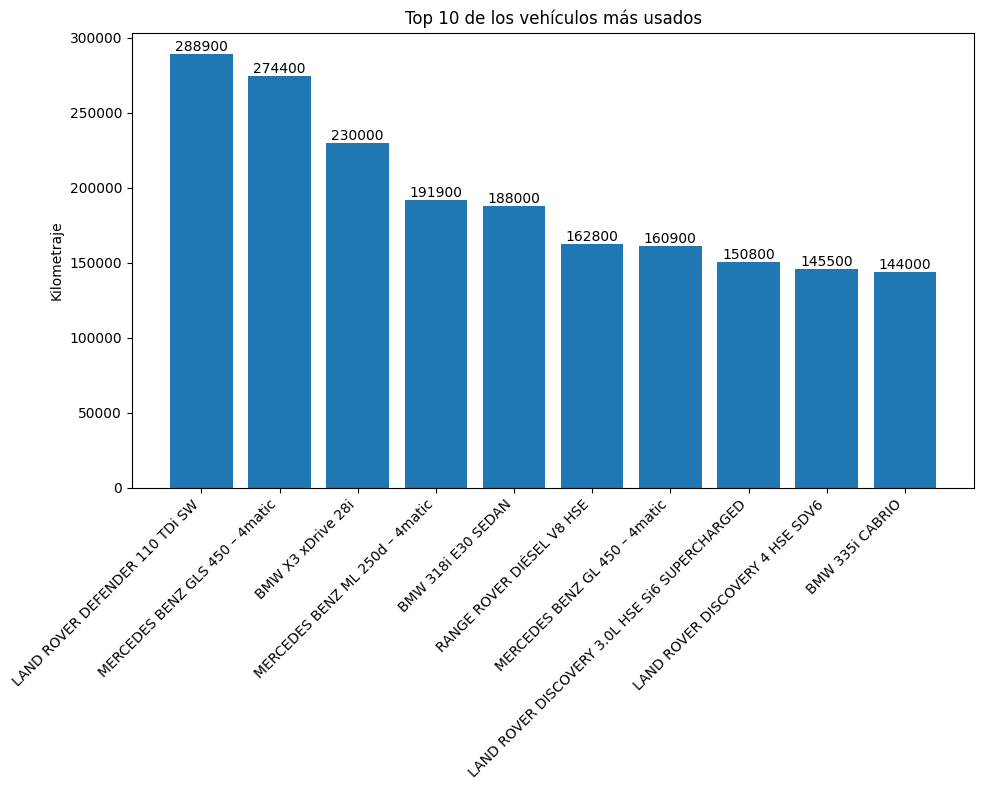

In [426]:
fig, ax = plt.subplots(figsize = (10, 8))
bars = ax.bar(mas_usados['Nombre'], mas_usados['Kilometraje'])
ax.set_ylabel('Kilometraje')
ax.set_title('Top 10 de los vehículos más usados')
ax = plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
  
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Parte 7
- g) Aplique a la variable con el tipo de combustible código disyuntivo completo.

In [467]:
df_encode = df.copy()

In [468]:
df_combustible = pd.get_dummies(df_encode['Combustible'], dtype='int', drop_first=False)
df_combustible[:3]

,Diésel,Diésel / Híbrido,Eléctrico,Gasolina,Gasolina / Híbrido,Híbrido
0,0,0,1,0,0,0
1,0,0,1,0,0,0
2,1,0,0,0,0,0


In [469]:
df_combustible = df_combustible.astype('category') 

In [470]:
df_encode = pd.concat([df_encode, df_combustible], axis=1)
df_encode = df_encode.drop(columns=['Combustible'])

In [471]:
df_encode

,Nombre,Precio,Año,Kilometraje,Motor (CC),Diésel,Diésel / Híbrido,Eléctrico,Gasolina,Gasolina / Híbrido,Híbrido
0,BMW iX xDRIVE 40 Sport,59000,2024,19900.0,N/A,0,0,1,0,0,0
1,AUDI RS e-TRON GT quattro,86000,2023,15900.0,N/A,0,0,1,0,0,0
2,TOYOTA HILUX SRV 2.8L DIÉSEL,55000,2023,67900.0,2755,1,0,0,0,0,0
3,TOYOTA HILUX SRV 2.8L DIÉSEL,55000,2023,70200.0,2755,1,0,0,0,0,0
4,MERCEDES BENZ E 300 AMG,57000,2021,40900.0,1.991,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
213,MERCEDES BENZ GL 350d AMG – 4matic,37000,2015,101700.0,2987,1,0,0,0,0,0
214,MERCEDES BENZ CLS 53 AMG 4matic +,95000,2019,20300.0,3000,0,0,0,1,0,0
215,PORSCHE TAYCAN ELÉCTRICO,72000,2021,33000.0,N/A,0,0,1,0,0,0
216,MERCEDES BENZ C 180 2015.,22000,2015,108500.0,1595,0,0,0,1,0,0


In [472]:
df_encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Nombre              218 non-null    object  
 1   Precio              218 non-null    int64   
 2   Año                 218 non-null    int64   
 3   Kilometraje         218 non-null    float64 
 4   Motor (CC)          218 non-null    object  
 5   Diésel              218 non-null    category
 6   Diésel / Híbrido    218 non-null    category
 7   Eléctrico           218 non-null    category
 8   Gasolina            218 non-null    category
 9   Gasolina / Híbrido  218 non-null    category
 10  Híbrido             218 non-null    category
dtypes: category(6), float64(1), int64(2), object(2)
memory usage: 10.6+ KB


## Parte 8
- h) Muestre con un gráfico la matriz de correlaciones. Interprete al menos dos correlaciones.  

In [ ]:
# para no desestimar la variable x tener variables categoricas.
df_encode['Motor_num'] = pd.to_numeric(df_encode['Motor (CC)'], errors='coerce')

In [492]:
df_corr = df_encode.drop(columns=['Nombre', 'Motor (CC)'])
matriz = df_corr.corr()

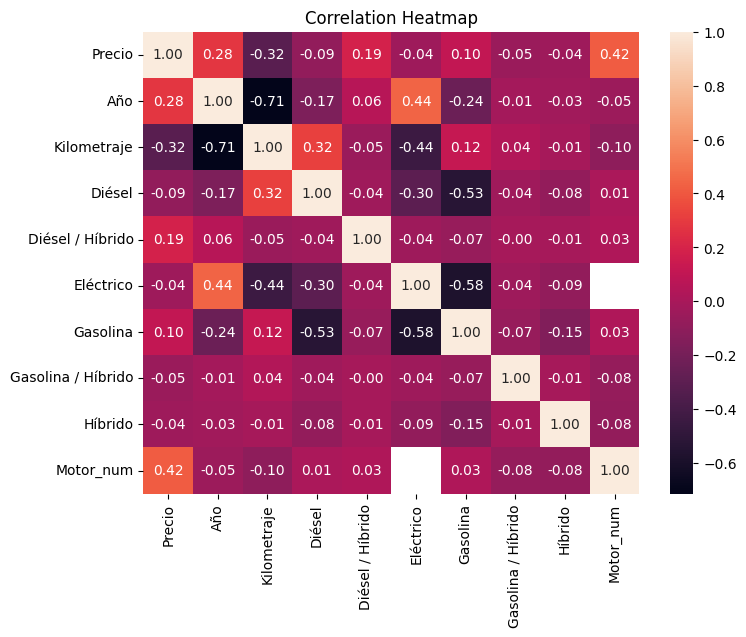

In [493]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

- Podemos ver que el `Motor_num` tiene una correlación medianamente fuerte y positiva con el `Precio` (0.42), es decir, que al subir el precio sube los CC del Motor. Lo que representa un comportamiento normal, porque entre más centimetros cubicos de motor tenga el vehículo, el precio del tiende a ascender.
- `Año` y `Eléctrico` tambien presentan una correlación medianamente fuerte y positiva (0.44). Este comportamiento me parece curioso y pensando en que los carros eléctricos se han vuelto populares, se ha visto un incremento conforme pasan los años en la flota vehicular de carros electricos.
- Otro dato curioso es que tenmos una correlación fuerte y negativa entre `Año` y `Kilometraje` (-0.71). Nos indica que los vehículos mas recientes tienden a tener menos kilometraje, lo cual tiene sentido, ya que un carro 2025 ha tenido menos tiempo en circulacion que uno del año 2000, por ejemplo.